# Loss Landscape Visualization

Sweeps all pairs of trainable AdEx parameters over a grid, simulates at each point,
and plots the loss surfaces as:
1. A lower-triangle grid of 2D contour plots (21 pairs)
2. Individual 3D surface plots with contour projection (Ackley-style)

In [1]:
import copy
import logging
import time
from itertools import combinations

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import config
from matplotlib import cm

from ADoptEX.core.data import crop_to_stim_window, load_trace
from ADoptEX.core.parameters import NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.loss.mse import MSELossConfig, make_mse_loss_fn
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.WARNING, format="%(message)s")

## 1. Load & Crop Data

In [2]:
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
)

data = crop_to_stim_window(trace, max_duration_ms=500.0)
print(
    f"Cropped: {data.n_samples} samples, {data.stim_duration_ms:.1f} ms, {data.n_spikes} spikes"
)

Cropped: 5000 samples, 500.0 ms, 2 spikes


## 2. Setup Cell & Loss Function

In [3]:
from ADoptEX.loss import (
    extract_experimental_features,
    GuarinoLossConfig,
    make_guarino_loss_fn,
)

initial_params = dict(NAUD_PARAMETERS["adaptation"])
initial_params["v_threshold"] = 0.0

training_config = TrainingConfig(
    optimizer="adam",
    learning_rate=0.01,
    n_epochs=1,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
)

current_nA = jnp.array(data.current * initial_params["C_m"] / 1000.0)

cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_nA=current_nA,
    dt_ms=data.dt_ms,
    config=training_config,
)

target_voltage = jnp.array(data.voltage)
stim_end_index = data.stim_end_idx  # already 0-based in cropped trace

# loss_name = 'MSE'
# loss_fn = make_mse_loss_fn(
#     cell=cell,
#     data_stimuli=data_stimuli,
#     t_max=t_max,
#     dt_ms=data.dt_ms,
#     exp_voltage=target_voltage,
#     stim_end_index=data.stim_end_idx,
#     loss_config=MSELossConfig(normalize=False, clamp_threshold=None),
# )


# Extract target features from experimental trace (hard spike detection)
exp_features = extract_experimental_features(
    voltage_trace=target_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=stim_end_index,
)

loss_name = "Guarino"
loss_fn = make_guarino_loss_fn(
    cell=cell,
    data_stimuli=data_stimuli,
    t_max=t_max,
    dt_ms=data.dt_ms,
    exp_features=exp_features,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=stim_end_index,
    loss_config=GuarinoLossConfig(
        weight_spike_count=0.0
    ),
)


# Build param name -> index mapping
param_index = {}
for i, p in enumerate(trainable_params):
    for k in p:
        param_index[k.replace("AdEx_", "")] = i

PARAM_NAMES = list(param_index.keys())
N_PARAMS = len(PARAM_NAMES)

loss_init = loss_fn(trainable_params)
print(f"Initial loss: {float(loss_init):.4f}")
print(f"Trainable parameters ({N_PARAMS}): {PARAM_NAMES}")
print(f"Initial parameters: {initial_params}")


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Initial loss: 10.2726
Trainable parameters (8): ['capacitance', 'g_L', 'E_L', 'v_T', 'v_reset', 'tau_w', 'a', 'b']
Initial parameters: {'C_m': 200.0, '

## 3. Sweep All Parameter Pairs

For each of the C(7,2) = 21 pairs, build a grid over their PARAM_BOUNDS and
evaluate the loss. Non-swept parameters stay at their default values.

In [4]:
GRID_SIZE = 20  # 20x20 per pair; 21 pairs * 400 = 8400 simulations

pairs = list(combinations(range(N_PARAMS), 2))
print(f"{len(pairs)} parameter pairs, {GRID_SIZE}x{GRID_SIZE} grid each")
print(f"Total simulations: {len(pairs) * GRID_SIZE**2}")

28 parameter pairs, 20x20 grid each
Total simulations: 11200


In [5]:
# Storage for all grids
grids = {}  # (i, j) -> {"X": ..., "Y": ..., "Z": ...}

t_start = time.time()

for pair_idx, (pi, pj) in enumerate(pairs):
    px, py = PARAM_NAMES[pi], PARAM_NAMES[pj]
    bx, by = PARAM_BOUNDS[px], PARAM_BOUNDS[py]

    x_vals = np.linspace(bx.min, bx.max, GRID_SIZE)
    y_vals = np.linspace(by.min, by.max, GRID_SIZE)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.full((GRID_SIZE, GRID_SIZE), np.nan)

    ix, iy = param_index[px], param_index[py]

    pxrc = f"AdEx_{px}" if px != "capacitance" else px
    pyrc = f"AdEx_{py}" if py != "capacitance" else py
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            params_rc = copy.deepcopy(trainable_params)
            params_rc[ix] = {pxrc: jnp.array([X[r, c]])}
            params_rc[iy] = {pyrc: jnp.array([Y[r, c]])}
            try:
                Z[r, c] = float(loss_fn(params_rc))
            except Exception:
                Z[r, c] = np.nan

    grids[(pi, pj)] = {"X": X, "Y": Y, "Z": Z}

    elapsed = time.time() - t_start
    eta = elapsed / (pair_idx + 1) * (len(pairs) - pair_idx - 1)
    print(
        f"  [{pair_idx+1:2d}/{len(pairs)}] {px:>8s} vs {py:<8s}  "
        f"loss=[{np.nanmin(Z):.1f}, {np.nanmax(Z):.1f}]  "
        f"elapsed={elapsed:.0f}s  ETA={eta:.0f}s"
    )

print(f"\nTotal time: {time.time() - t_start:.0f}s")

  [ 1/28] capacitance vs g_L       loss=[8.8, 12.1]  elapsed=51s  ETA=1371s
  [ 2/28] capacitance vs E_L       loss=[6.8, 11.3]  elapsed=102s  ETA=1326s
  [ 3/28] capacitance vs v_T       loss=[2.2, 249639.8]  elapsed=155s  ETA=1294s
  [ 4/28] capacitance vs v_reset   loss=[8.6, 45.6]  elapsed=215s  ETA=1287s
  [ 5/28] capacitance vs tau_w     loss=[8.8, 20.4]  elapsed=275s  ETA=1264s
  [ 6/28] capacitance vs a         loss=[8.9, 12.8]  elapsed=337s  ETA=1237s
  [ 7/28] capacitance vs b         loss=[8.9, 29.3]  elapsed=400s  ETA=1201s
  [ 8/28]      g_L vs E_L       loss=[5.6, 11.8]  elapsed=464s  ETA=1159s
  [ 9/28]      g_L vs v_T       loss=[2.4, 249639.0]  elapsed=525s  ETA=1109s
  [10/28]      g_L vs v_reset   loss=[8.8, 46.6]  elapsed=589s  ETA=1061s
  [11/28]      g_L vs tau_w     loss=[8.8, 22.4]  elapsed=659s  ETA=1018s
  [12/28]      g_L vs a         loss=[8.9, 13.5]  elapsed=727s  ETA=970s
  [13/28]      g_L vs b         loss=[8.9, 30.7]  elapsed=793s  ETA=915s
  [14/28]   

## 4. Triangle Grid — All Pairs (2D Contour)

Lower-triangle matrix: row = second parameter, column = first parameter.
Each cell shows a filled contour of the loss landscape for that pair.

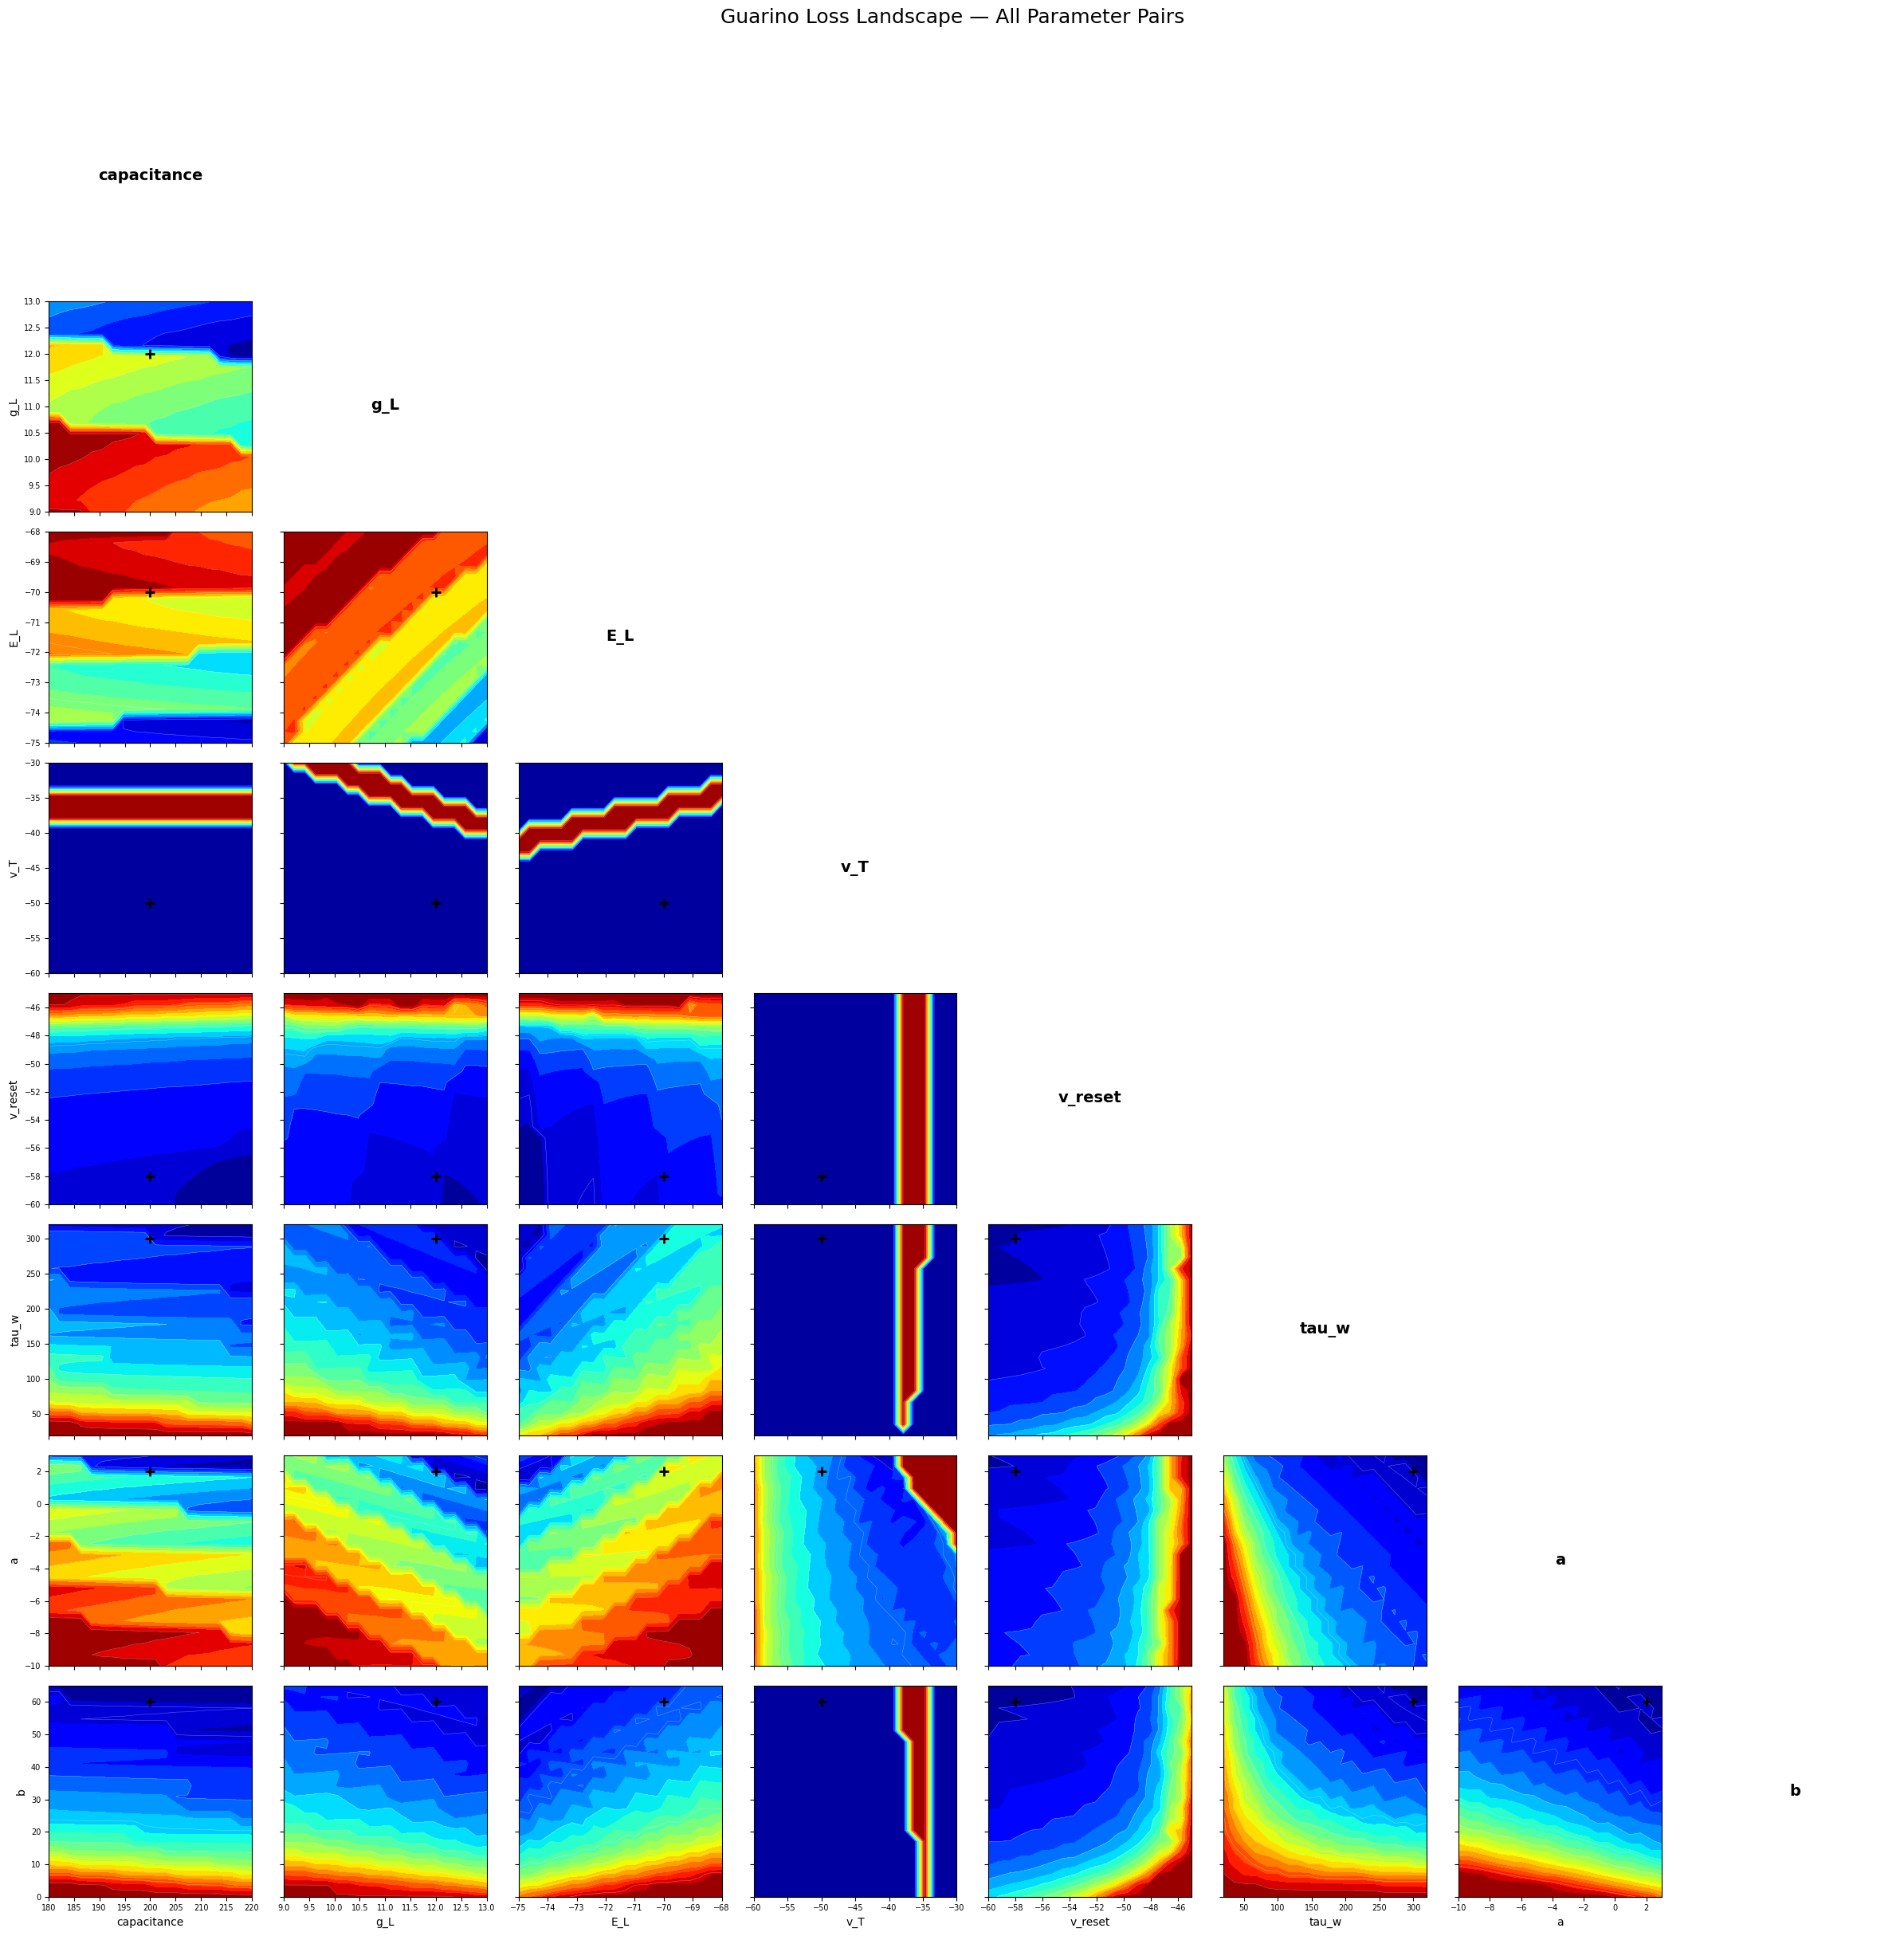

Saved to guarino_loss_landscape_grid.png


In [6]:
fig, axes = plt.subplots(
    N_PARAMS,
    N_PARAMS,
    figsize=(3 * N_PARAMS, 3 * N_PARAMS),
    squeeze=False,
)

# Hide all axes first
for ax_row in axes:
    for ax in ax_row:
        ax.set_visible(False)

# Fill lower triangle
for (pi, pj), g in grids.items():
    ax = axes[pj, pi]  # row=pj (y-axis param), col=pi (x-axis param)
    ax.set_visible(True)

    Z_plot = np.clip(g["Z"], np.nanmin(g["Z"]), np.nanpercentile(g["Z"], 95))
    ax.contourf(g["X"], g["Y"], Z_plot, levels=20, cmap=cm.jet)
    ax.contour(
        g["X"], g["Y"], Z_plot, levels=8, colors="white", linewidths=0.3, alpha=0.5
    )

    def map_name_to_trainable_params(s):
        if s == "capacitance":
            return "C_m"
        return s
    # Mark default params
    ax.plot(
        initial_params[map_name_to_trainable_params(PARAM_NAMES[pi])],
        initial_params[map_name_to_trainable_params(PARAM_NAMES[pj])],
        "k+",
        markersize=8,
        markeredgewidth=2,
    )

    # Labels on edges only
    if pj == N_PARAMS - 1:  # bottom row
        ax.set_xlabel(PARAM_NAMES[pi], fontsize=10)
    else:
        ax.set_xticklabels([])
    if pi == 0:  # left column
        ax.set_ylabel(PARAM_NAMES[pj], fontsize=10)
    else:
        ax.set_yticklabels([])

    ax.tick_params(labelsize=7)

# Diagonal labels
for i in range(N_PARAMS):
    ax = axes[i, i]
    ax.set_visible(True)
    ax.text(
        0.5,
        0.5,
        PARAM_NAMES[i],
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle(f"{loss_name} Loss Landscape — All Parameter Pairs", fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig(
    f"{loss_name.lower()}_loss_landscape_grid.png", dpi=150, bbox_inches="tight"
)
plt.show()
print(f"Saved to {loss_name.lower()}_loss_landscape_grid.png")

## 5. Individual 3D Surface Plots

Ackley-style 3D surface with contour projection for each parameter pair.

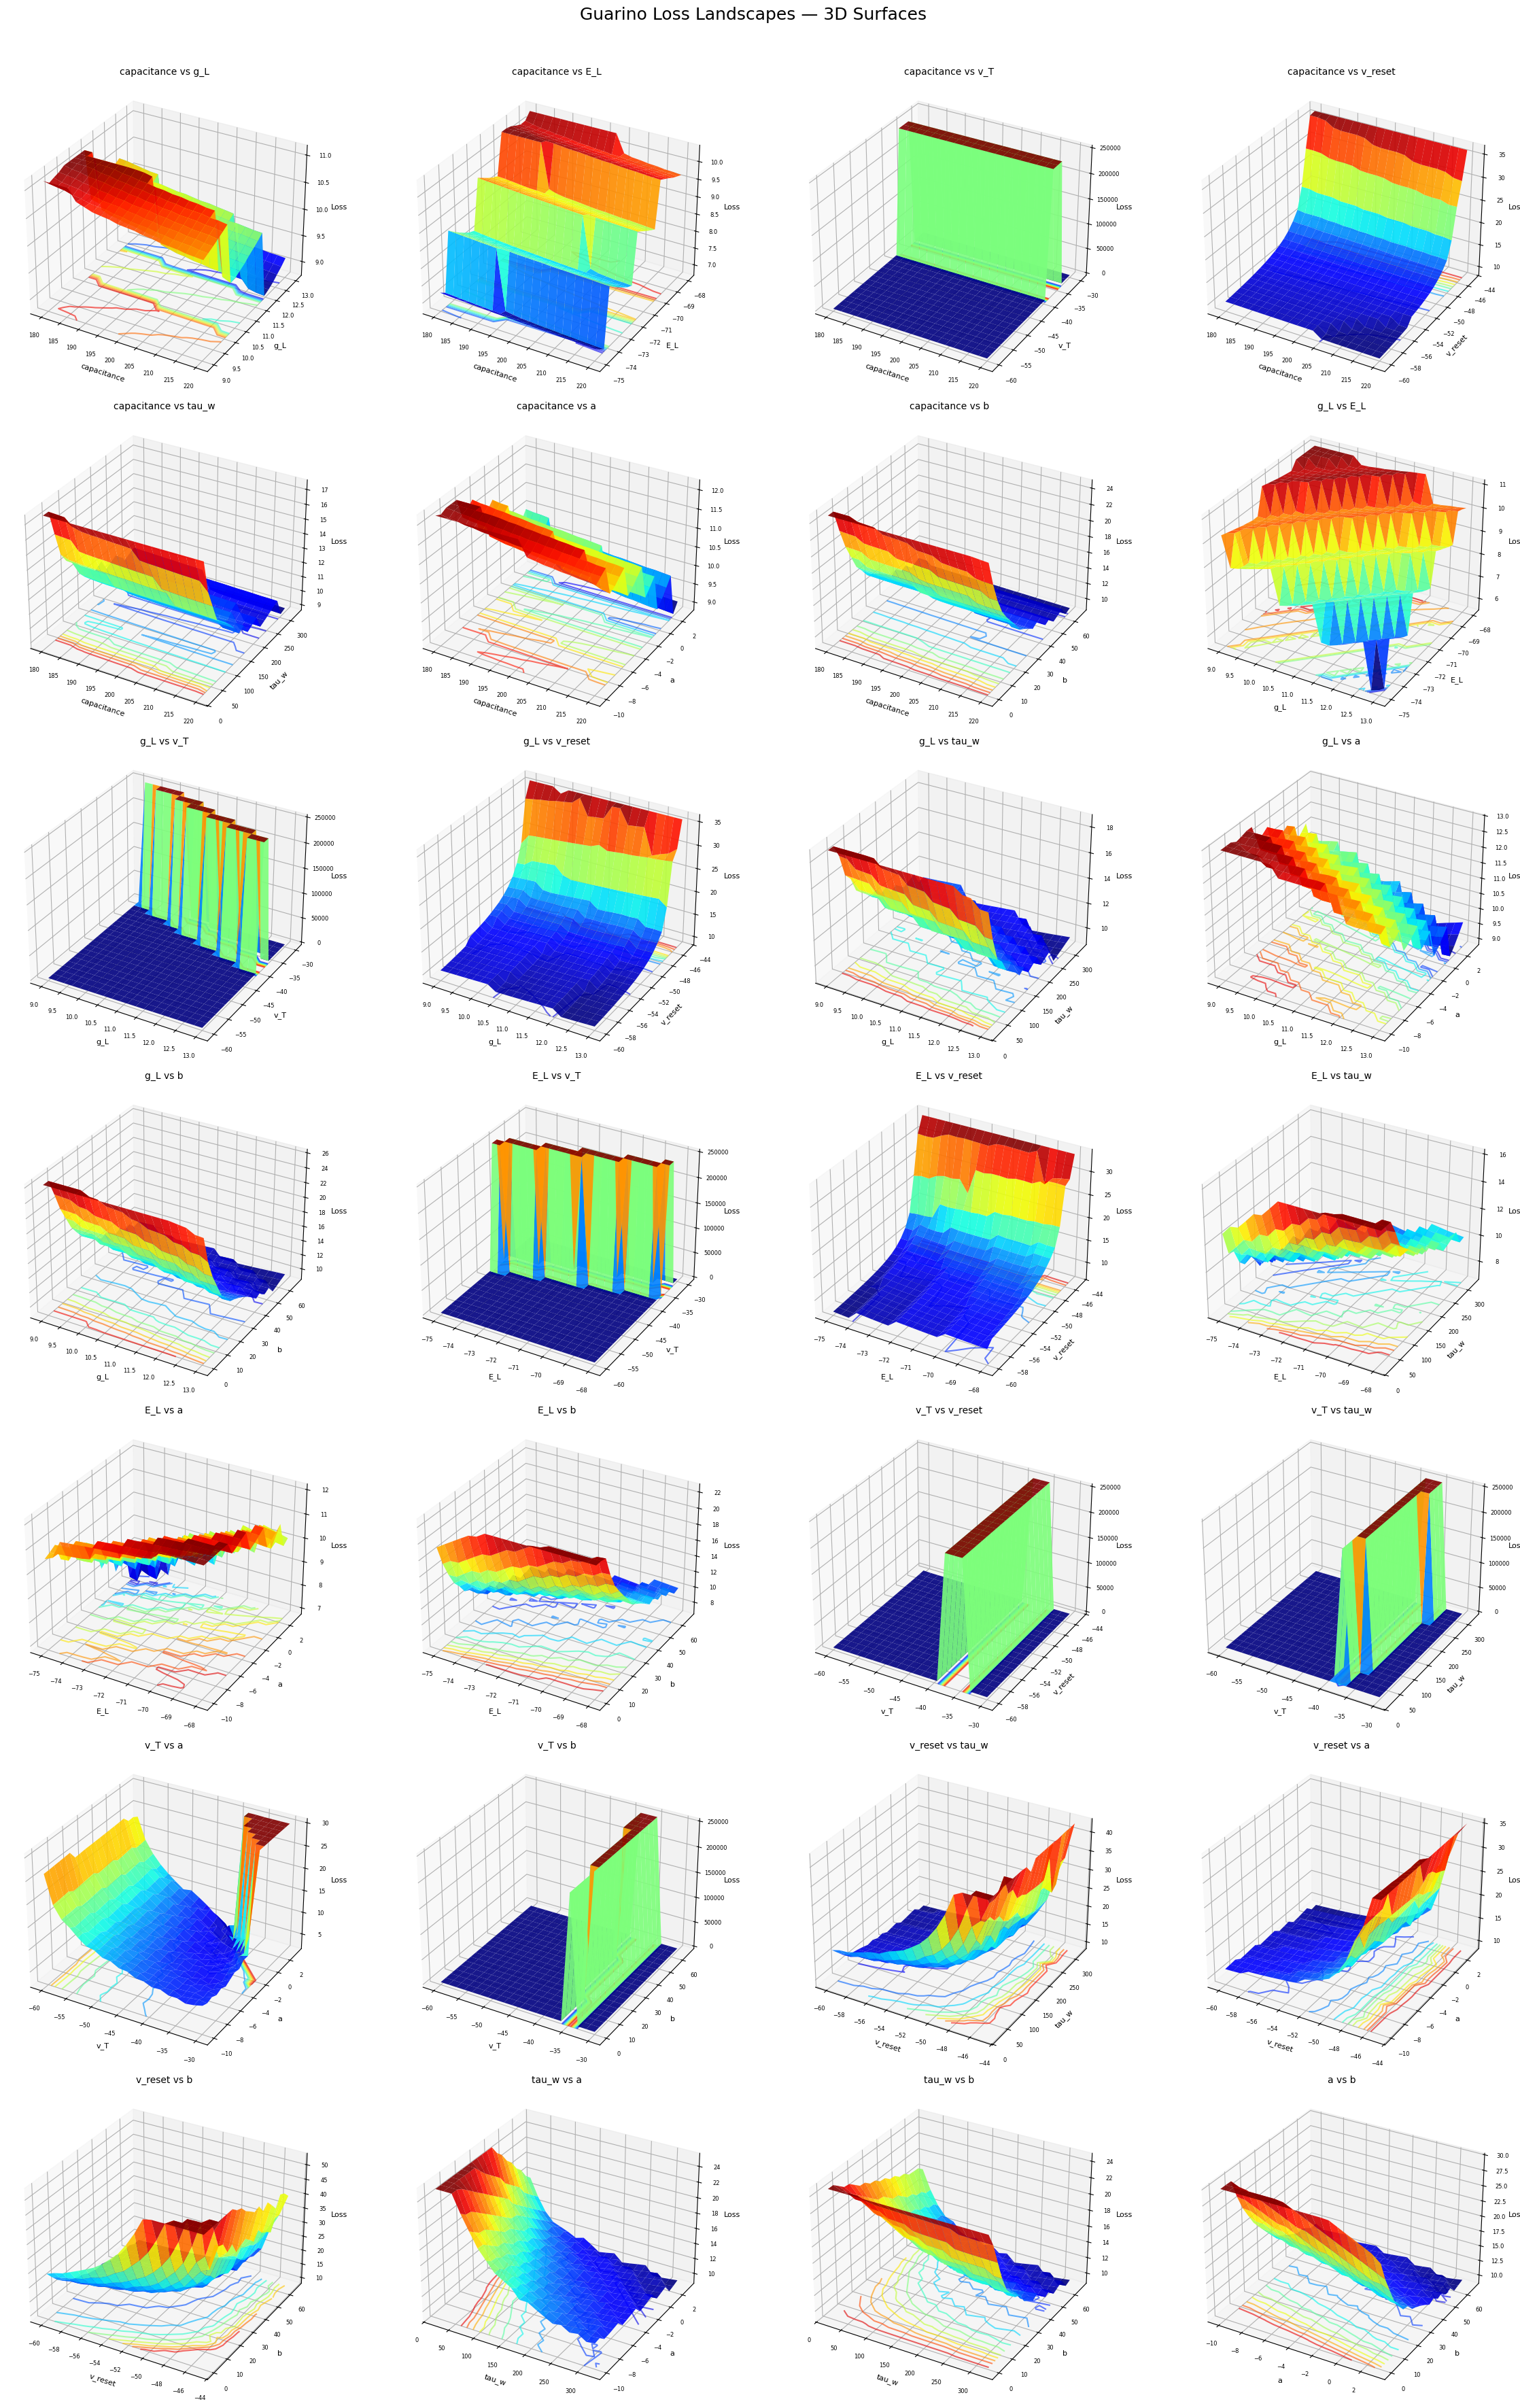

Saved to guarino_loss_landscape_3d_all.pdf


In [7]:
n_pairs = len(pairs)
n_cols = 4
n_rows = (n_pairs + n_cols - 1) // n_cols

fig = plt.figure(figsize=(6 * n_cols, 5 * n_rows))

for idx, (pi, pj) in enumerate(pairs):
    px, py = PARAM_NAMES[pi], PARAM_NAMES[pj]
    g = grids[(pi, pj)]

    ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection="3d")

    Z_plot = np.clip(g["Z"], np.nanmin(g["Z"]), np.nanpercentile(g["Z"], 95))

    surf = ax.plot_surface(
        g["X"],
        g["Y"],
        Z_plot,
        cmap=cm.jet,
        edgecolor="none",
        alpha=0.9,
        rstride=1,
        cstride=1,
    )

    # Contour projection on the floor
    z_floor = ax.get_zlim()[0]
    ax.contour(
        g["X"],
        g["Y"],
        Z_plot,
        levels=10,
        zdir="z",
        offset=z_floor,
        cmap=cm.jet,
        alpha=0.6,
    )

    ax.set_xlabel(px, fontsize=8, labelpad=2)
    ax.set_ylabel(py, fontsize=8, labelpad=2)
    ax.set_zlabel("Loss", fontsize=8, labelpad=2)
    ax.set_title(f"{px} vs {py}", fontsize=10, pad=2)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=30, azim=-60)

# Hide unused subplots
for idx in range(n_pairs, n_rows * n_cols):
    fig.add_subplot(n_rows, n_cols, idx + 1).set_visible(False)

fig.suptitle(f"{loss_name} Loss Landscapes — 3D Surfaces", fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig(
    f"{loss_name.lower()}_loss_landscape_3d_all.pdf", dpi=150, bbox_inches="tight"
)
plt.show()
print(f"Saved to {loss_name.lower()}_loss_landscape_3d_all.pdf")